<a href="https://colab.research.google.com/github/ujwaljain506-hash/ml-journey/blob/main/day18_confusion_matrix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt

In [2]:
from sklearn.preprocessing import LabelEncoder

In [3]:
import pandas as pd

In [4]:
df = pd.read_csv("/content/drive/MyDrive/matches.csv")
print("File Loaded")

File Loaded


In [5]:
le = LabelEncoder()
df['team1_encoded'] = le.fit_transform(df['team1'])
df['team2_encoded'] = le.fit_transform(df['team2'])
df['venue_encoded']=le.fit_transform(df['venue'])
df['toss_winner_encoded']=le.fit_transform(df['toss_winner'])
df['toss_decision_encoded']=le.fit_transform(df['toss_decision'])

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X = df[['team1_encoded', 'team2_encoded', 'venue_encoded', 'toss_winner_encoded', 'toss_decision_encoded']]
y = df['winner']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
print(X_train.shape)
print(X_test.shape)

(604, 5)
(152, 5)


In [10]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

In [11]:
X_train.isnull().sum()

,0
team1_encoded,0
team2_encoded,0
venue_encoded,0
toss_winner_encoded,0
toss_decision_encoded,0


In [12]:
y_train.isnull().sum()

np.int64(4)

In [13]:
df[df['winner'].isnull()]

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,...,player_of_match,venue,umpire1,umpire2,umpire3,team1_encoded,team2_encoded,venue_encoded,toss_winner_encoded,toss_decision_encoded
300,301,IPL-2011,Delhi,21-05-2011,Delhi Daredevils,Pune Warriors,Delhi Daredevils,bat,no result,0,...,NaN,Feroz Shah Kotla,SS Hazare,RJ Tucker,NaN,3,9,9,3,0
545,546,IPL-2015,Bangalore,29-04-2015,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,no result,0,...,NaN,M Chinnaswamy Stadium,JD Cloete,PG Pathak,NaN,13,10,17,10,1
570,571,IPL-2015,Bangalore,17-05-2015,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore,field,no result,0,...,NaN,M Chinnaswamy Stadium,HDPK Dharmasena,K Srinivasan,NaN,3,13,17,13,1
744,11340,IPL-2019,Bengaluru,30-04-2019,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,no result,0,...,NaN,M. Chinnaswamy Stadium,Nigel Llong,Ulhas Gandhe,Anil Chaudhary,13,10,19,10,1


In [14]:
df = df.dropna(subset=['winner'])

In [15]:
df.shape

(752, 23)

In [16]:
X = df[['team1_encoded', 'team2_encoded', 'venue_encoded', 'toss_winner_encoded', 'toss_decision_encoded']]
y = df['winner']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
y_train.isnull().sum()

np.int64(0)

In [18]:
model.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [19]:
y_pred = model.predict(X_test)

In [20]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred))

0.48344370860927155


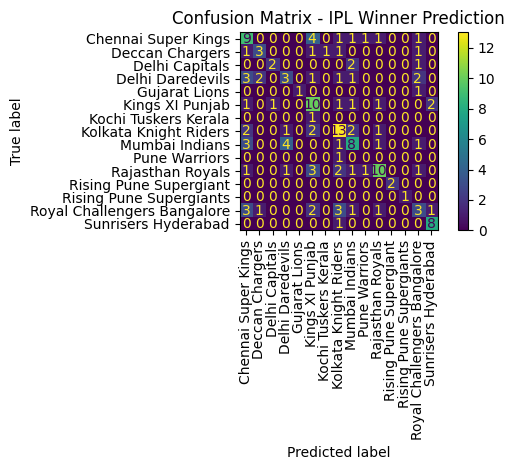

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(xticks_rotation=90)
plt.title('Confusion Matrix - IPL Winner Prediction')
plt.tight_layout()
plt.show()


How to Read a Confusion Matrix
A confusion matrix is a grid that shows how well your model predicted each team.
Each row = actual winner (what really happened)
Each column = predicted winner (what the model guessed)
Each number = count of matches with that exact actual + predicted combination

The simple rule:

Numbers on the diagonal = correct predictions (actual = predicted) ✅
Numbers off the diagonal = mistakes (actual ≠ predicted) ❌


Example with 3 matches:
MatchActual WinnerModel Predicted1CSKCSK ✅2MICSK ❌3CSKMI ❌
This gives us these counts:

"Actual CSK, Predicted CSK" → 1 (match 1 — correct)
"Actual MI, Predicted CSK" → 1 (match 2 — wrong)
"Actual CSK, Predicted MI" → 1 (match 3 — wrong)


Reading your real matrix:

9 in CSK row, CSK column → 9 matches where CSK actually won AND model correctly said CSK ✅
4 in CSK row, MI column → 4 matches where CSK actually won BUT model wrongly predicted MI ❌

Bigger diagonal numbers = model is better at predicting that team.
Numbers off diagonal = model got confused between those two teams